# Model Factory — what I worked on

**Jeffrey Stall (jstall)** · CSED 504 · Part 1 (A1 Computer Vision)

## 1. Summary

This is my summary of what I contributed, what I decided along the way, and what I actually learned
from it. It is deliberately about the *process* rather than the model math.  I set out to build a
**model factory**: the tooling to train and evaluate models efficiently, so that part 2 can be about
the harder problem instead of about fighting the plumbing. That was the goal in our
[original proposal](https://docs.google.com/document/d/1zP7TbLEXAUgCuIkICG1_eT-bb0IjNyJxVdL3mipfwuQ/edit?tab=t.0#heading=h.5x0d5h95i329),
and one of the primary areas I focused on:

1. I deliberately did *not* try to invent an architecture. I used CIFAR-10 and CIFAR-100 with
known-good architectures to get a baseline I could trust, then scaled the same pipeline up to
ImageNet-32 to see what breaks when the dataset gets 25× bigger.

2. Most of my time went into **performance tuning the GPUs**, because that is what decides whether
an experiment takes 4 minutes or 40 days. The headline: I took ResNet-18 training from about **4,150
images per second at 30% GPU utilization to about 21,500 at 84%**, on the same hardware. I also
examined where multiple GPUs could enable parallelism, and (surprisingly) where they could not.
These speedups is what made it practical to run the whole study, controls and all.

3. I also got a real answer to the question we set up in the first place: **when does a Transformer
actually beat a CNN?** The honest answer, at the scales we could run: it does not — the CNN's early lead
shrinks to a dead heat, and a resolution ceiling caps both families. Section 7 has the numbers, including
the 1.3-point win I first reported and then disproved with a proper seed sweep.


## 2. Connecting CSED 502 to PyTorch in a production environment

In 502 we wrote everything by hand in numpy: the forward pass, the backward pass, a `Solver` class,
and `np.random.choice` to grab a batch. Moving to PyTorch, I wanted to keep that mental model rather
than treat the framework as a black box, so I mapped the pieces one to one:

| CSED 502 (numpy, by hand) | this project (PyTorch) |
|---|---|
| `Solver._step()` | `train_one_epoch()` in [`train_loop.py`](train_loop.py) |
| hand-written backward pass | `loss.backward()` — autograd builds the graph for us |
| `np.random.choice(num_train, batch_size)` | a fresh permutation each epoch, so every image is seen exactly once |
| a loop over a numpy array | a loader that keeps the data on the GPU and hands back augmented batches |

**Where I used AI:** I used it to translate the 502 concepts into the PyTorch idiom and, more usefully,
to tell me what PyTorch was now doing *implicitly* that I used to do by hand: optimizer state,
scheduler stepping, and where autograd inserts itself. That mapping is what let me trust the code
instead of copying it.

**What I learned:** The mental model transfers cleanly, but the *performance* model does not. In 502
the arithmetic was the expensive part. On a GPU the arithmetic is nearly free, and the cost moves to
moving data around and to how many separate operations you ask the GPU to run. Almost every problem I
hit for the rest of the project was a version of that one idea.


## 3. CIFAR-10 and CIFAR-100 as the baseline

I started here on purpose. CIFAR is small enough to iterate on in minutes, and I already had
known-good hyperparameters from 502, so I could tell the difference between "my code is wrong" and
"this model is just hard to train."

**How I simplified:** I reused the 502 CIFAR recipe rather than tuning from scratch, and I
**parameter-matched the ViT to the ResNet** (about 11.0M against 11.7M). That was a deliberate call:
if the Transformer had been much bigger, any result would just have been "bigger model wins" and the
comparison would have been worthless.

**Where I used AI:** Porting the 502 model builders into [`models.py`](models.py), and setting up the
ViT for 32×32 images: a standard ViT chops an image into 16-pixel patches, which on a 32-pixel image
leaves almost nothing, so it needed a patch size of 4 and a matching stem.

**What I learned:**

1. **A CNN and a Transformer want different recipes.** The CNN wants SGD with momentum; the ViT wants
   AdamW and a warmup. This is not a detail: using one recipe for both would have quietly decided the
   result before the experiment ran.
2. **Augmentation is not universally good.** Mixup helps the ViT and actively *hurts* the CNN. When I
   gave the CNN the ViT's augmentation as a control, it got **worse** (33.9%, down from 36.9%).
3. **A setting that rescues one model can quietly cost another.** I added gradient clipping because
   ResNet-50 was diverging to NaN without it. It fixed ResNet-50 and cost **ResNet-18 about five
   points** (36.9% clipped against 41.7% unclipped). That one took a while to spot, because nothing
   errors: the model just quietly trains worse. Clipping now defaults off for ResNet-18 only.


## 4. Making it run on everyone's machine

Our group is spread across Windows, Mac, Linux, and Google Colab, so the pipeline had to work on all
of them or people would be blocked. I leaned on the device-detection and profiling work I had already
done for CSED 502 and 503 rather than starting over. Additional, I incorporated NVidia's performance
tools to get realtime GPU utilization information during training.

The problems that actually cost time were not the obvious ones:

- **Windows and macOS were silently running single-process data loading.** The code enabled DataLoader
  workers only when the start method was `fork`, which is Linux-only. On Windows and Mac it silently
  fell back to zero workers, so one CPU core did all the work while the GPU waited. Nothing warned us;
  it was just slow. This was the single biggest fix.
- **`channels_last` is a win or a trap depending on the precision.** Paired with bf16 it measured
  **1.34×** on an RTX 2000 Ada. Paired with fp16 it was **3.5× slower**. Same flag, opposite result.
- **Apple Silicon needs a fallback** for operations MPS has not implemented, and that fallback only
  covers the forward pass, not the backward one.
- **`torch.compile` is not available on Windows** (it needs Triton), so that whole lever was off the
  table for our main machine.

**What I improved.** Once I understood the pipeline was the bottleneck, I stopped trying to make the
data loader faster and removed it: at 32x32 the entire dataset fits in GPU memory, so I load it once
and do the augmentation on the GPU. Then I wrote [`train_fleet.py`](train_fleet.py) so a two-GPU
machine trains two models at once instead of leaving a card idle.


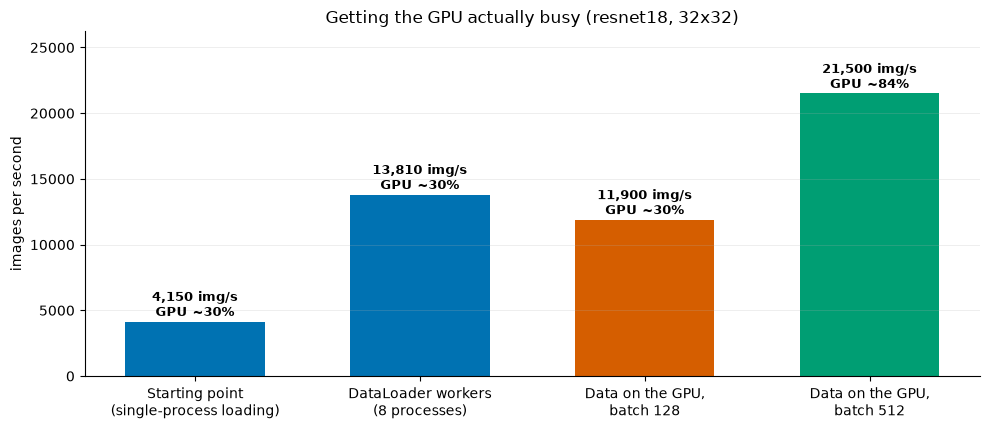

Overall: 4,150 to 21,500 img/s, about 5.2×, and GPU utilization from ~30% to ~84%.


In [1]:
# The performance story in one picture. These are the measured throughputs at each step of the
# investigation, on the workstation, training resnet18 on 32×32 images. The interesting bar is the
# third one: the step that went backwards is the one that told me what was actually wrong.
import matplotlib.pyplot as plt

# Each step, what changed, and what it measured. The utilization column is why the first number was
# so misleading: the GPU was mostly idle, so the problem was never the model.
steps = [
    ('Starting point\n(single-process loading)', 4150,  '~30%'),
    ('DataLoader workers\n(8 processes)',        13810, '~30%'),
    ('Data on the GPU,\nbatch 128',              11900, '~30%'),
    ('Data on the GPU,\nbatch 512',              21500, '~84%'),
]
labels = [s[0] for s in steps]
speeds = [s[1] for s in steps]
utils  = [s[2] for s in steps]

# Color the step that got slower differently: it is the one that falsified my assumption, and it
# deserves to stand out rather than hide in a row of blue bars.
colors = ['#0072B2', '#0072B2', '#D55E00', '#009E73']

fig, ax = plt.subplots(figsize=(10, 4.4))
bars = ax.bar(labels, speeds, color=colors, width=0.62)

# Label each bar with its throughput and the GPU utilization that went with it.
for bar, spd, u in zip(bars, speeds, utils):
    ax.annotate(f'{spd:,} img/s\nGPU {u}', xy=(bar.get_x() + bar.get_width() / 2, spd),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('images per second')
ax.set_title('Getting the GPU actually busy (resnet18, 32x32)')
ax.set_ylim(0, max(speeds) * 1.22)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

print('Overall: 4,150 to 21,500 img/s, about 5.2×, and GPU utilization from ~30% to ~84%.')

**The step that taught me the most is the one that went backwards.** After adding worker
processes the GPU was *still* only about 30% busy, and I assumed it was still starving for data. So I
tested that assumption directly: I put the data and the augmentation entirely on the GPU, which makes
the data source effectively free, and measured again.

It got **slower** (11,900 against 13,810 img/s). A free data source making things slower means the
data was never the bottleneck. The real problem was that at batch 128 a small model finishes each
batch faster than the CPU can queue up the next one, so the GPU sits waiting between batches.
Raising the batch to 512 gave it enough work per launch to stay busy, and that is where the 21,500
img/s came from.

**One note on these numbers, so they line up with section 8.** They are the measurements from the
investigation itself, recorded as each change landed. Another round of loop fixes came after the last
one (removing a per-step GPU-to-CPU sync), and the committed CIFAR runs now sustain about **34,800
img/s** — the table in section 8 reads that straight off the run records. So the 5.2x here is the
improvement I could attribute step by step while working, not the final ceiling.

I would not have found that by guessing. I found it by making a prediction, measuring it, and being
wrong in a way that was informative. The full writeup is in
[`report_factory_performance.ipynb`](report_factory_performance.ipynb).


## 5. Scaling up to ImageNet-32

CIFAR is 50,000 images. ImageNet-32 is 1.28 million — 25× more — and it ships as JPEG images packed
inside parquet files. Decoding those on the fly would mean decoding 1.28 million JPEGs *every epoch*
on the CPU, which would have made the GPU work I had just done pointless.

**How I simplified it.** I decode the whole thing exactly **once**, up front, into a flat array of raw
bytes (3.9 GB on disk, see [`imagenet_prepare.py`](imagenet_prepare.py)). After that step, training
never touches JPEG, PIL, or parquet again — it just indexes into an array. This is not an optimization
I did for fun; it is the step that made the dataset usable at all on our hardware.

**Where I used AI.** Two places. First, writing the parquet-to-array conversion with multiple worker
processes, including a Windows-specific constraint I would not have predicted: Windows spawns fresh
processes rather than forking, so the decode function has to live at module level to be pickled to the
workers. Second, writing the sanity checks that run after the conversion.

**What I learned.**

1. **Those sanity checks earned their keep immediately.** The dataset is stored **sorted by class**, so
   the first 10,000 rows contain only a handful of the 1,000 classes. If I had taken a "quick subset"
   off the front to test with, which is exactly what I would have done, every result from it would
   have been quietly meaningless. The check proves the file is sorted and prints a warning to always
   shuffle.
2. **One-time preprocessing is worth much more than a faster inner loop.** I spent a while making the
   training step faster; converting the data once was worth more than all of it, because it removed the
   work entirely instead of speeding it up.


## 6. Splitting "fast" from "full"

By this point I had a real problem that was not technical. The notebooks had grown into a mix of
"watch it work" and "produce the actual result," and those two things want opposite settings. A
notebook that takes four hours is useless for understanding, and a notebook that trains for two epochs
produces numbers nobody should quote.

So I split them, and made the split explicit:

- **The notebooks are fast pipeline checks.** A couple of epochs on a subset, a minute or two, enough
  to watch the whole loop work end to end.
- **All real training runs from the console** — [`train_run.py`](train_run.py) for one model,
  [`train_fleet.py`](train_fleet.py) for a batch across both GPUs. Results are written to `runs/`, and
  the report notebooks read them back off disk.

This mattered for the team more than it mattered for me. A group member on a laptop can run the fast
check and understand the pipeline without a workstation; the workstation runs the fleet overnight. I
also published the eight trained models to a GitHub Release with a `load_model()` helper, so anyone can
use our results **without training anything at all**.

**Where I used AI.** Building the unified CLI, the two-GPU scheduler, and the live
[`dashboard.py`](dashboard.py) that shows both cards, per-run curves, throughput, and an ETA.

**What I learned.**

1. **The split removed a whole category of confusion.** Before it, a two-epoch smoke run had appended
   junk epochs to a real run's history and corrupted a plot. Separating the two, and giving throwaway
   runs their own names, made that impossible rather than unlikely.
2. **Making results *shareable* did more for the group's speed than any single speedup.** Publishing
   the trained models meant nobody had to reproduce an overnight run to look at a number. That was
   worth more hours than the 5x throughput win.


## 7. What I actually found: CNNs against Transformers

This is the question the factory existed to answer, and the honest answer is more specific — and more
interesting — than "Transformers are better," or even than the crossover I thought I had at first.

- On **CIFAR-10** (5,000 images per class) the CNN leads by **7.6 points**.
- On **CIFAR-100** (500 images per class) the CNN leads by **11.7 points** — a *wider* gap on the same
  total amount of data.
- On **ImageNet-32** (1,281 per class) the CNN and the ViT finish **level, about 42.5% each**, once both
  are trained to a converged budget.

My first pass reported a 1.3-point ViT win on ImageNet-32 and I did not trust it — the seed sweep below
showed why. The two charts and the write-up under them tell the whole story: where the CNN's advantage
comes from, why it shrinks, and why neither architecture pulls ahead at the largest scale we ran.

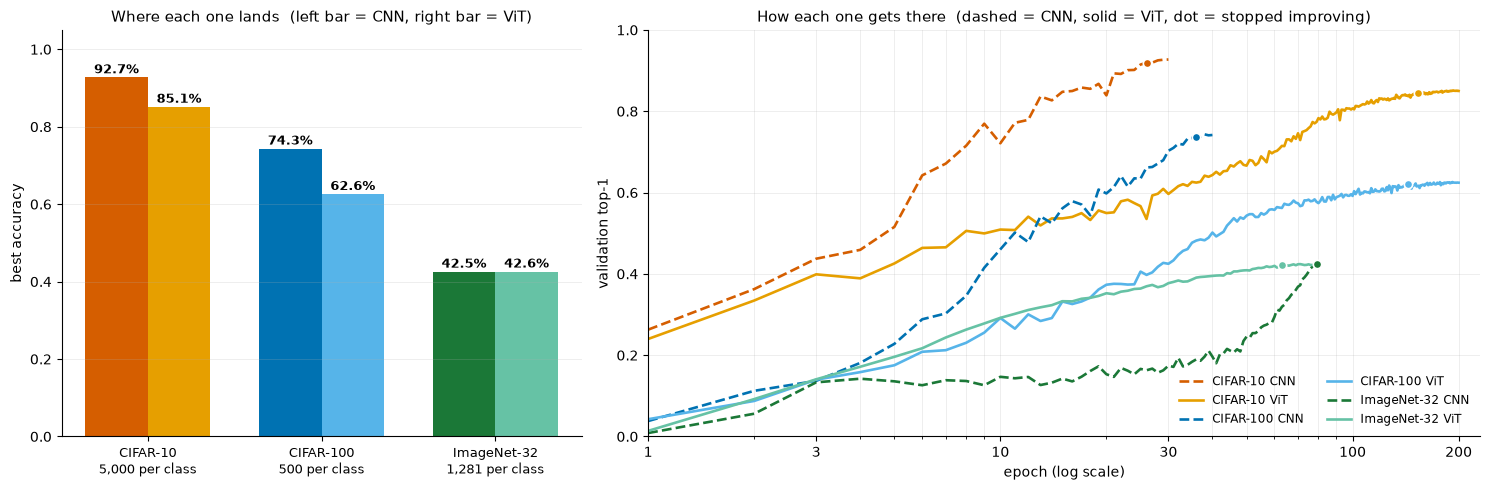

CIFAR-10  CNN 92.7% vs ViT 85.1%   CNN leads by 7.6
CIFAR-100 CNN 74.3% vs ViT 62.6%   CNN leads by 11.7  (same total data as CIFAR-10)
ImageNet  CNN 42.5% vs ViT 42.6%   ViT leads by 0.0

run                 settled at    of  epochs after
  CIFAR-10 CNN              26    30             4
  CIFAR-10 ViT             153   200            47
  CIFAR-100 CNN             36    40             4
  CIFAR-100 ViT            144   200            56
  ImageNet-32 CNN           79    80             1
  ImageNet-32 ViT           63    80            17


In [2]:
# The two charts that carry the finding. Everything here is read from the console runs on disk, so
# the numbers move when the runs do.
import json
import matplotlib.pyplot as plt

# One hue per dataset, and within a dataset the CNN takes the darker shade and the ViT the lighter one.
# That pairing is deliberate. Holding CIFAR-10 up against ImageNet-32 is not a meaningful comparison --
# different class counts, different difficulty, different scales -- but holding a CNN against a ViT on
# the same data is the entire question. So the two things worth comparing share a hue and differ only
# in shade, and the things not worth comparing are told apart by hue instead.
#
# Both charts use this same table, so a bar on the left and its curve on the right are obviously the
# same run. Dashed against solid says CNN against ViT a second way, for when two shades sit close.
RUNS_PLOT = [
    ('cifar10_resnet18',  'CIFAR-10 CNN',    '#D55E00', '--'),
    ('cifar10_vit',       'CIFAR-10 ViT',    '#E69F00', '-'),
    ('cifar100_resnet18', 'CIFAR-100 CNN',   '#0072B2', '--'),
    ('cifar100_vit',      'CIFAR-100 ViT',   '#56B4E9', '-'),
    ('imagenet32_resnet18_s1', 'ImageNet-32 CNN', '#1B7837', '--'),
    ('imagenet32_vit_s1',      'ImageNet-32 ViT', '#66C2A5', '-'),
]
COLOR = {tag: c for tag, _, c, _ in RUNS_PLOT}

# best_top1: a run's headline number, read off its own result file. The recorded value is a fallback
# only, for a fresh clone that has not trained anything yet -- so no number on this page is typed in by
# hand, and none of them can go stale while the runs move underneath.
def best_top1(tag, recorded):
    try:
        return json.load(open(f'runs/{tag}_result.json'))['best_top1']
    except (OSError, KeyError, ValueError):
        return recorded


# seed_mean: the average best-top1 across a run's seeds. The ImageNet-32 headline is the converged
# 80-epoch result averaged over three seeds, not a single run -- a one-off 1.3-point gap there turned
# out to be noise once the seeds were in, which is the story section 7 tells.
def seed_mean(tags, recorded):
    xs = [x for x in (best_top1(t, None) for t in tags) if x is not None]
    return sum(xs) / len(xs) if xs else recorded


# val_curve: one run's validation accuracy at every epoch, straight from its per-epoch log.
def val_curve(tag):
    try:
        with open(f'runs/{tag}.jsonl') as f:
            return [json.loads(line)['val']['top1'] for line in f if line.strip()]
    except OSError:
        return []

# settled_epoch: the first epoch within 1% of the run's own best, which is a far more useful mark than
# the best epoch itself. The learning rate anneals to zero, so accuracy always jumps at the very end
# and the best epoch is nearly always the last one -- marking it would say nothing. This marks where
# the curve stopped meaningfully improving, so whatever comes after it is the flat part.
def settled_epoch(ys):
    best = max(ys)
    return next(i + 1 for i, v in enumerate(ys) if v >= 0.99 * best)

# The three datasets, paired CNN against ViT, in order of how much data there is per class.
CNN80 = ['imagenet32_resnet18_s1', 'imagenet32_resnet18_s2', 'imagenet32_resnet18_s3']
VIT80 = ['imagenet32_vit_s1', 'imagenet32_vit_s2', 'imagenet32_vit_s3']

rows = [
    ('CIFAR-10\n5,000 per class',    'cifar10_resnet18',       best_top1('cifar10_resnet18', 0.9273),
                                      'cifar10_vit',            best_top1('cifar10_vit', 0.8513)),
    ('CIFAR-100\n500 per class',     'cifar100_resnet18',      best_top1('cifar100_resnet18', 0.7432),
                                      'cifar100_vit',           best_top1('cifar100_vit', 0.6259)),
    ('ImageNet-32\n1,281 per class', 'imagenet32_resnet18_s1', seed_mean(CNN80, 0.4253),
                                      'imagenet32_vit_s1',      seed_mean(VIT80, 0.4256)),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1.6]})

# Left: where each one lands. Each bar takes its own run's color, so it matches its curve on the right.
w = 0.36
for i, (label, cnn_tag, cnn_v, vit_tag, vit_v) in enumerate(rows):
    for offset, tag, val in ((-w / 2, cnn_tag, cnn_v), (w / 2, vit_tag, vit_v)):
        ax1.bar(i + offset, val, w, color=COLOR[tag])
        ax1.annotate(f'{val:.1%}', xy=(i + offset, val), xytext=(0, 3),
                     textcoords='offset points', ha='center', fontsize=9, fontweight='bold')

ax1.set_xticks(range(len(rows))); ax1.set_xticklabels([r[0] for r in rows], fontsize=9)
ax1.set_ylabel('best accuracy'); ax1.set_ylim(0, 1.05)
ax1.set_title('Where each one lands  (left bar = CNN, right bar = ViT)', fontsize=11)
ax1.grid(axis='y', alpha=0.25, linewidth=0.6)
ax1.spines[['top', 'right']].set_visible(False)

# Right: all six runs, epoch by epoch. The axis is logarithmic because the budgets differ by five
# times -- on a linear axis four of the six curves would be crushed into the first fifth of the width.
for tag, label, color, style in RUNS_PLOT:
    ys = val_curve(tag)
    if not ys:
        continue

    ax2.plot(range(1, len(ys) + 1), ys, color=color, linestyle=style, linewidth=1.9, label=label)

    # Mark where the run settled. Everything to the right of the dot is the flat part, so a dot with a
    # long tail after it is a run that finished early, and a dot sitting on the final epoch is a run
    # that never flattened at all.
    se = settled_epoch(ys)
    ax2.plot(se, ys[se - 1], marker='o', markersize=6, color=color,
             markeredgecolor='white', markeredgewidth=1.2, zorder=5)

ax2.set_xscale('log')
ax2.set_xticks([1, 3, 10, 30, 100, 200])
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xlabel('epoch (log scale)'); ax2.set_ylabel('validation top-1')
ax2.set_title('How each one gets there  (dashed = CNN, solid = ViT, dot = stopped improving)', fontsize=11)
ax2.set_ylim(0, 1.0); ax2.set_xlim(1, 230)
ax2.grid(alpha=0.25, linewidth=0.6, which='both')
ax2.legend(frameon=False, fontsize=8.5, loc='lower right', ncol=2)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

print(f'CIFAR-10  CNN {rows[0][2]:.1%} vs ViT {rows[0][4]:.1%}   CNN leads by {(rows[0][2]-rows[0][4])*100:.1f}')
print(f'CIFAR-100 CNN {rows[1][2]:.1%} vs ViT {rows[1][4]:.1%}   CNN leads by {(rows[1][2]-rows[1][4])*100:.1f}  (same total data as CIFAR-10)')
print(f'ImageNet  CNN {rows[2][2]:.1%} vs ViT {rows[2][4]:.1%}   ViT leads by {(rows[2][4]-rows[2][2])*100:.1f}')
print()

# Where each run settled, and how many epochs it then spent going nowhere.
print(f'{"run":18s} {"settled at":>11s} {"of":>5s} {"epochs after":>13s}')
for tag, label, _, _ in RUNS_PLOT:
    ys = val_curve(tag)
    if ys:
        se = settled_epoch(ys)
        print(f'  {label:18s} {se:9d} {len(ys):5d} {len(ys) - se:13d}')

**Chart on the left:** the CNN wins the first two datasets, and on the third the two draw level. Each
dataset has its own hue, with the CNN in the darker shade, so the pair worth comparing sits together and
every bar matches its curve on the right.

**Chart on the right:** all six runs, epoch by epoch, on a logarithmic epoch axis — the budgets differ
by more than 5x, and on a linear axis four of the curves would be crushed into the first fifth of the
width. The ImageNet-32 pair are the converged 80-epoch runs now, not the 40-epoch ones I started with,
and the reason for that swap is the whole story below.

---

### The result changed once I trained it properly

The first version of this page reported a 1.3-point ImageNet-32 win for the ViT — and then spent three
paragraphs explaining why I did not believe it. The main reason: the CNN was still climbing on its final
epoch, so I had almost certainly stopped it before it was done. I named the experiment that would settle
it — both models at double the epoch budget, three seeds each — and ran it overnight.

It settled. **At a converged 80 epochs, the CNN and the ViT are the same:**

| arm (80 epochs, 3 seeds) | mean | spread |
|---|---|---|
| CNN (ResNet-18) | **42.53%** | 0.14 |
| ViT | **42.56%** | 0.28 |

The gap is **0.03 points, inside a 0.28-point noise band** — there is nothing there. And the 1.3-point
lead was exactly what I suspected: an under-trained CNN. Given the epochs it needed, the CNN gained
**+0.84** while the ViT, already converged, drifted **−0.45**, and they met in the middle.

I am oddly glad it went this way. The honest version of the page had already predicted it; running the
experiment turned a hedge into a result — which is the point of flagging your own weak claims instead of
hoping nobody checks them.

---

### The bigger finding: a ceiling nothing gets past

With the budget fixed, the capacity controls say something cleaner than I expected. **Every model lands
in the same half-point, whatever its size:**

| model | params | 80 epochs |
|---|---|---|
| ResNet-18 | 11.7M | 42.58% |
| ResNet-50 | 25.5M | 42.43% |
| ViT | 11.0M | 42.40% |
| ViT-Base | **85.9M** | 42.59% |

Eight times the parameters moved the result by less than the noise. That is not an architecture story
and not a capacity story — it is a **data-and-resolution ceiling**. At 32x32, ImageNet-32 gives up about
42.5% to any of these models and no more.

I think resolution is the binding constraint, and there is a concrete reason. At 32x32 with a patch size
of 4, the ViT sees an 8x8 grid — **64 patch tokens**. That is a very short sequence for a mechanism whose
whole advantage is relating distant parts of an image to each other, and a small canvas for a convolution
stack too. You cannot buy past that with a bigger network; you would need more pixels. That is the one
thing I did not try, and it is the experiment I would run next (section 8).

---

### Did we rig the race? (the 40-epoch controls)

Before the seed sweep, I had already checked the 40-epoch lead was not just the ViT's recipe. These
controls stand on their own terms — they are what convinced me the gap, while real at 40 epochs, did not
come from the augmentation:

| control (40 epochs) | result | what it says |
|---|---|---|
| CNN baseline | 36.86% | the starting point |
| CNN + 50% more epochs (60) | 37.06% | more training buys +0.2 points |
| CNN + 60 epochs **and** mixup | 33.91% | the ViT's augmentation makes the CNN **worse** |
| CNN, 2x parameters (ResNet-50) | 41.16% | capacity did not rescue it |
| ViT, 8x parameters (ViT-Base) | 41.47% | nor on the other side |

The mixup row is the sharp one: handing the CNN the ViT's augmentation drops it three points, so a CNN
cannot simply borrow the ViT's recipe. The loose end is that these all ran with gradient clipping while
the CNN I quote runs without it — which is exactly the gap the 80-epoch no-clip seed sweep tied off.

---

### The per-class finding, which is the part I am most pleased with

This one survives everything. CIFAR-10 and CIFAR-100 hold *exactly the same number of images* — 50,000.
The only thing that differs is how many belong to each class: 5,000 against 500. The CNN's lead
**widens** from 7.6 points to 11.7 as the per-class count drops. So what starves the Transformer is not
the total amount of data, it is the amount **per class** — a distinction I could only draw because the
two datasets are matched on total size, which the ImageNet numbers alone never could.

Put beside the ImageNet result, it draws the whole arc in one line: the CNN's edge is largest when data
per class is thinnest, shrinks as it grows, and reaches a dead heat by ~1,300 images per class — at which
point the resolution ceiling caps both families together.

---

### The dots, and the one thing I still cannot rule out

The dots mark where each run *stopped improving* — the first epoch within 1% of its own best — not where
it peaked. Marking the peak says nothing: the learning rate anneals to zero, so the best epoch is almost
always the last one regardless of whether the model converged. What follows a dot is the flat part.

| run | settles at | of | tail |
|---|---|---|---|
| CIFAR-10 ViT | 153 | 200 | 47 wasted |
| CIFAR-100 ViT | 144 | 200 | 56 wasted |
| ImageNet-32 ViT (80ep) | 63 | 80 | 17 |
| ImageNet-32 CNN (80ep) | 79 | 80 | **1** |

The CIFAR ViTs plainly overtrain — a quarter of each run buys nothing. The ImageNet CNN is the honest
caveat: even at 80 epochs it settles on epoch 79, so it is *still* barely flattening. I will not claim it
could not edge a fraction higher with more. What I can claim is narrower and firmer than the 1.3-point
gap I started with: at a fair, converged budget the two families are level to within the noise, and no
amount of extra parameters moves either one.

---

## 8. Preparing for the next round

### Predicting the cost before spending the night

The thing that repeatedly slowed us down was not knowing how long a run would take *before* committing
to it. That is how you lose an evening. So the question I wanted answered was the one you would ask
first: can we work out the cost from the dataset, the model, and the hardware, instead of discovering
it by trial and error?

We can, and the estimator in [`perf/`](perf/) does it with a roofline model. A training step can only
be limited by one of three things, so the estimate is the slowest of the three:

```
t_step = max(  flops_per_step / (MFU x peak_TFLOPS),   <- compute-bound
               bytes_per_step / (0.7 x bandwidth),     <- memory-bound
               kernels_per_step x launch_overhead )    <- launch-bound

total  = epochs x (steps_per_epoch x t_step + t_eval) + startup
```

That is the equation in the shape I was hoping for, with each term coming from somewhere different:

| term | where it comes from | this is the... |
|---|---|---|
| `flops_per_step` | model architecture x batch size | **model cost** |
| `steps_per_epoch` | dataset size / batch size | **dataset size** |
| `peak_TFLOPS`, `bandwidth`, `launch_overhead` | measured once per machine by the Tier 0 probe | **hardware capability** |
| `MFU` | the honest unknown: what fraction of peak you actually reach | the fudge factor |

`MFU` (model FLOPs utilization) is the one term you cannot look up, because it depends on the model,
the batch size, and the machine together. The estimator handles that by reporting a *band* rather than
a single number, and by narrowing the band with a short calibration run on the real step when accuracy
matters more than speed.

The most useful thing the model produces is not actually the time — it is `binding_term`, which says
*which* of the three limits you hit. That turns out to decide whether a cheap estimate works at all.

In [3]:
# Could we have predicted the ImageNet-32 cost from the CIFAR runs we already had? Both datasets are
# 32x32 and use the same models, so the per-image work is nearly identical -- only the number of images
# changes, by a factor of about 26. If throughput carries across, the prediction is simple arithmetic.
import json

# Images per epoch. This is the only term that differs between the three datasets.
N_IMAGES = {'cifar10': 50_000, 'cifar100': 50_000, 'imagenet32': 1_281_167}

RUNS_COST = [
    ('cifar10_resnet18',  'cifar10',    'resnet18'),
    ('cifar100_resnet18', 'cifar100',   'resnet18'),
    ('imagenet32_resnet18', 'imagenet32', 'resnet18'),
    ('cifar10_vit',       'cifar10',    'vit'),
    ('cifar100_vit',      'cifar100',   'vit'),
    ('imagenet32_vit',      'imagenet32', 'vit'),
]

# mean_img_s: the run's average training throughput, taken from its own per-epoch log rather than from
# wall clock, so evaluation and startup do not pollute the number we are trying to carry across.
def mean_img_s(tag):
    d = json.load(open(f'runs/{tag}_result.json'))
    ips = [h['train']['img_s'] for h in d.get('history', [])
           if 'train' in h and 'img_s' in h['train']]
    return (sum(ips) / len(ips) if ips else float('nan')), d['epochs'], d['seconds']

print(f'{"run":20s} {"dataset":11s} {"epochs":>7s} {"train img/s":>12s} {"wall (min)":>11s}')
tput = {}
for tag, ds, model in RUNS_COST:
    ips, epochs, secs = mean_img_s(tag)
    tput.setdefault(model, {})[ds] = ips
    print(f'{tag:20s} {ds:11s} {epochs:7d} {ips:12,.0f} {secs/60:11.1f}')

# The test: take only the CIFAR-10 throughput, multiply by the images ImageNet-32 actually has, and
# see how close that lands to the run we really measured.
print('\nPredicting ImageNet-32 from the CIFAR-10 throughput alone:')
print(f'  {"model":9s} {"predicted":>10s} {"actual":>9s} {"error":>8s}   throughput carried across')
for tag, model in (('imagenet32_resnet18', 'resnet18'), ('imagenet32_vit', 'vit')):
    d = json.load(open(f'runs/{tag}_result.json'))
    predicted = d['epochs'] * N_IMAGES['imagenet32'] / tput[model]['cifar10'] / 60
    actual = d['seconds'] / 60
    ratio = tput[model]['imagenet32'] / tput[model]['cifar10']
    print(f'  {model:9s} {predicted:8.1f}m {actual:8.1f}m {100*(predicted-actual)/actual:+7.1f}%   '
          f'{ratio:.2f}x of the CIFAR rate')

run                  dataset      epochs  train img/s  wall (min)
cifar10_resnet18     cifar10          30       34,812         1.2
cifar100_resnet18    cifar100         40       34,831         1.5
imagenet32_resnet18  imagenet32       40       22,278        38.9
cifar10_vit          cifar10         200       15,368        12.3
cifar100_vit         cifar100        200       15,771        12.2
imagenet32_vit       imagenet32       40       14,903        58.2

Predicting ImageNet-32 from the CIFAR-10 throughput alone:
  model      predicted    actual    error   throughput carried across
  resnet18      24.5m     38.9m   -36.9%   0.64x of the CIFAR rate
  vit           55.6m     58.2m    -4.5%   0.97x of the CIFAR rate


**The ViT prediction lands within 5%. The CNN prediction is 37% low.** Same hardware, same image size,
same code — and one of them is trivially predictable while the other is not.

The reason is the binding term, which is why that field matters more than the time estimate. The ViT is
**compute-bound**: it does enough arithmetic per image that nothing else is close, so its rate depends
on the model and the GPU and not on which dataset the images came from. Throughput carries across
unchanged, and the cost is genuinely just *images x epochs / rate*.

ResNet-18 at 32x32 is **not** compute-bound — it is small enough that memory traffic sets the pace,
which is the same finding that drove the whole performance investigation in section 4. So when the
resident dataset grows from 147 MB (CIFAR) to 3.9 GB (ImageNet-32), the random access pattern stops
fitting the way it did and the same model on the same images runs **36% slower per image**. Nothing
about the model changed. Only the size of the array it indexes into.

**So the answer to "could we have predicted ImageNet-32 from CIFAR" is: yes for the ViT, no for the
CNN, and the roofline tells you in advance which case you are in.** That is the part I would not have
guessed, and it is worth more than the estimate itself. A cheap scaling argument is safe when you are
compute-bound and actively misleading when you are not.

**Honest limits of what we have.** The Tier 1 estimate reports a range, not a number, because MFU is
genuinely unknown up front — the default band spans 5% to 40% of peak, which is wide enough to plan
around but not to schedule to the minute. Narrowing it needs the Tier 2 calibration, which times the
real training step on the real machine for a couple of minutes. That is still enormously cheaper than
discovering a ten-hour run the hard way, which is the whole point.

**The next experiment I would run.** Section 7 settled the epoch question: at a converged budget the
two families are level, so the ImageNet-32 result is a resolution ceiling, not an architecture one. The
interesting question is no longer "does the ViT win" but "what breaks the ceiling," and the answer is
more pixels rather than more model — at 32x32 the ViT gets only 64 patch tokens where 64x64 would give
it 256. So the run I want next is **ImageNet-64 rather than ImageNet-32** — same models, same pipeline,
four times the sequence length. The factory takes it without a rewrite, since `IMG_SHAPE` in `imagenet_prepare.py` is a single
constant and the loaders read their shape from the array. The cost is honest though: four times the
pixels is roughly four times the data and the training time, which is exactly what the estimator above
exists to price before we commit a night to it.

**What I am carrying into part 2:**

1. **Measure before optimizing.** My first instinct about the bottleneck was wrong, and the measurement
   that proved it wrong was the most valuable thing I did.
2. **The bottleneck moves.** Fixing the data pipeline just promoted a different limit. Knowing which of
   the three it is — waiting on the CPU, waiting on launches, or genuinely computing — is the whole
   skill.
3. **Make results shareable early.** Publishing models so the group could use them without retraining
   bought back more time than any speedup.
4. **Repeat a run before believing it.** A single run is one sample. I learned this one the
   uncomfortable way, at the end.
5. **Keep the fast path and the real path separate.** Notebooks to understand, console to produce.

For part 2 this factory carries over almost unchanged: the data pipeline, the training CLI, the
scheduler, the dashboard, and the estimator are all dataset-agnostic. Swapping in text or audio means
writing a new loader and a new model builder, which is exactly the seam we designed for in the
proposal.


### Project Links

| where | what is there |
|---|---|
| [`report_factory_performance.ipynb`](report_factory_performance.ipynb) | the full performance investigation, with the measurements |
| [`report_crossover.ipynb`](report_crossover.ipynb) | the CNN vs Transformer findings |
| [`imagenet32_train.ipynb`](imagenet32_train.ipynb) | the ImageNet-32 scoreboard and the controls |
| [`train_run.py`](train_run.py), [`train_fleet.py`](train_fleet.py), [`dashboard.py`](dashboard.py) | the training CLI, the two-GPU scheduler, the live monitor |
| [`cifar_data.py`](cifar_data.py), [`imagenet_data.py`](imagenet_data.py), [`imagenet_prepare.py`](imagenet_prepare.py) | the data pipeline that made it fast |
| [`perf/`](perf/) | the training-time estimator, for planning the next round |